# 🎬 Análisis de Sentimientos - Introducción y Dataset IMDB

## Introducción al Análisis de Sentimientos con NLP

Este notebook educativo te introduce al mundo del **Natural Language Processing (NLP)** a través del **Análisis de Sentimientos**.

### Objetivos del Notebook:
1. **Entender qué es el Análisis de Sentimientos**
2. **Cargar y explorar** el dataset IMDB de reviews de películas
3. **Entender la tokenización** (convertir texto → números)
4. **Decodificar reviews** (números → texto legible)
5. **Analizar estadísticas** del dataset
6. **Visualizar ejemplos** de reviews positivas y negativas

### ¿Qué es el Análisis de Sentimientos?

Es una tarea de **clasificación** que determina si un texto expresa una opinión:
- **Positiva** ✅: "This movie is amazing!"
- **Negativa** ❌: "Terrible film, waste of time."

### Dataset: IMDB Movie Reviews
- **50,000 reviews** de películas
- **25,000 entrenamiento**, **25,000 prueba**
- **Balanceado**: 50% positivo, 50% negativo
- Ya incluido en Keras (descarga automática)

### Conexión con Proyectos Anteriores:
- 🔗 **predictor-titanic**: Misma tarea (clasificación binaria), pero con texto en lugar de features estructuradas
- 🔗 **fraude-detection**: Clasificación binaria, pero con features numéricas
- 🔗 **prediccion-temperatura**: LSTM, pero con secuencias de palabras en lugar de números

## Parte 1: Configuración Inicial

Importamos las librerías necesarias y configuramos el entorno.

In [18]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.datasets import imdb

# Configurar visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

print("✅ Librerías importadas correctamente")
print(f"🧠 TensorFlow versión: {tf.__version__}")

✅ Librerías importadas correctamente
🧠 TensorFlow versión: 2.19.0


In [19]:
# Configurar rutas del proyecto
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_RAW_DIR = PROJECT_DIR / 'data' / 'raw'
REPORTS_DIR = PROJECT_DIR / 'reports'

# Crear directorios si no existen
DATA_RAW_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Rutas configuradas:")
print(f"   - Proyecto: {PROJECT_DIR}")
print(f"   - Datos: {DATA_RAW_DIR}")
print(f"   - Reportes: {REPORTS_DIR}")

📁 Rutas configuradas:
   - Proyecto: /
   - Datos: /data/raw
   - Reportes: /reports


## Parte 2: Carga del Dataset IMDB

### ¿Qué es la Tokenización?

Las computadoras no entienden texto, solo números. Por eso, cada palabra se convierte en un número único:

```
Diccionario de palabras:
{
    "the": 1,
    "movie": 2,
    "is": 3,
    "great": 4,
    "terrible": 5,
    ...
}

Texto original:  "The movie is great"
Tokenizado:      [1, 2, 3, 4]
```

El dataset IMDB ya viene tokenizado (pre-procesado).

In [20]:
print("=" * 70)
print("📥 CARGANDO DATASET IMDB")
print("=" * 70)

print("\n⏳ Descargando dataset...")
print("   (Primera vez puede tardar 1-2 minutos. Después será instantáneo)\n")

# Cargar datos del dataset IMDB
# Retorna: (X_train, y_train), (X_test, y_test)
# X = reviews tokenizadas (listas de números)
# y = labels (0=negativo, 1=positivo)
# num_words=10000 = usar solo las 10,000 palabras más frecuentes
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print("✅ Dataset cargado exitosamente!")

📥 CARGANDO DATASET IMDB

⏳ Descargando dataset...
   (Primera vez puede tardar 1-2 minutos. Después será instantáneo)

✅ Dataset cargado exitosamente!


## Parte 3: Exploración Básica del Dataset

In [21]:
print("=" * 70)
print("📊 INFORMACIÓN BÁSICA DEL DATASET")
print("=" * 70)

print(f"\n📦 Tamaño del dataset:")
print(f"   - Training set: {len(X_train):,} reviews")
print(f"   - Test set: {len(X_test):,} reviews")
print(f"   - Total: {len(X_train) + len(X_test):,} reviews")

print(f"\n📊 Distribución de sentimientos (Training):")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    sentiment = "Positivo ✅" if label == 1 else "Negativo ❌"
    percentage = (count / len(y_train)) * 100
    bar = '█' * int(percentage / 2)
    print(f"   {sentiment}: {count:,} ({percentage:.1f}%) {bar}")

print(f"\n💡 El dataset está perfectamente balanceado (50%-50%)")

📊 INFORMACIÓN BÁSICA DEL DATASET

📦 Tamaño del dataset:
   - Training set: 25,000 reviews
   - Test set: 25,000 reviews
   - Total: 50,000 reviews

📊 Distribución de sentimientos (Training):
   Negativo ❌: 12,500 (50.0%) █████████████████████████
   Positivo ✅: 12,500 (50.0%) █████████████████████████

💡 El dataset está perfectamente balanceado (50%-50%)


### Entendiendo el Formato de los Datos

In [22]:
print("=" * 70)
print("🔍 FORMATO DE LOS DATOS")
print("=" * 70)

# Mostrar el primer review (tokenizado)
print(f"\n📝 Primer review (formato tokenizado):")
print(f"   Tipo: {type(X_train[0])}")
print(f"   Longitud: {len(X_train[0])} palabras (tokens)")
print(f"   Primeros 50 tokens: {X_train[0][:50]}")
print(f"   Label: {y_train[0]} ({'Positivo ✅' if y_train[0] == 1 else 'Negativo ❌'})")

print(f"\n💡 Cada número representa una palabra del vocabulario.")
print(f"   Números más bajos = palabras más frecuentes")
print(f"   Ejemplo: 1 = 'the', 2 = 'and', 3 = 'a', etc.")

🔍 FORMATO DE LOS DATOS

📝 Primer review (formato tokenizado):
   Tipo: <class 'list'>
   Longitud: 218 palabras (tokens)
   Primeros 50 tokens: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447]
   Label: 1 (Positivo ✅)

💡 Cada número representa una palabra del vocabulario.
   Números más bajos = palabras más frecuentes
   Ejemplo: 1 = 'the', 2 = 'and', 3 = 'a', etc.


## Parte 4: Análisis de Longitudes de Reviews

In [23]:
print("=" * 70)
print("📏 ANÁLISIS DE LONGITUDES")
print("=" * 70)

# Calcular longitudes
train_lengths = [len(review) for review in X_train]
test_lengths = [len(review) for review in X_test]

print(f"\n📊 Estadísticas de longitud (Training):")
print(f"   - Promedio: {np.mean(train_lengths):.1f} palabras")
print(f"   - Mediana: {np.median(train_lengths):.0f} palabras")
print(f"   - Mínimo: {np.min(train_lengths)} palabras")
print(f"   - Máximo: {np.max(train_lengths)} palabras")
print(f"   - Desviación estándar: {np.std(train_lengths):.1f} palabras")

print(f"\n💡 Las reviews varían mucho en longitud.")
print(f"   Algunas son muy cortas (pocas palabras), otras muy largas.")

📏 ANÁLISIS DE LONGITUDES

📊 Estadísticas de longitud (Training):
   - Promedio: 238.7 palabras
   - Mediana: 178 palabras
   - Mínimo: 11 palabras
   - Máximo: 2494 palabras
   - Desviación estándar: 176.5 palabras

💡 Las reviews varían mucho en longitud.
   Algunas son muy cortas (pocas palabras), otras muy largas.


/tmp/ipython-input-960576727.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([train_lengths, test_lengths], labels=['Training', 'Test'])


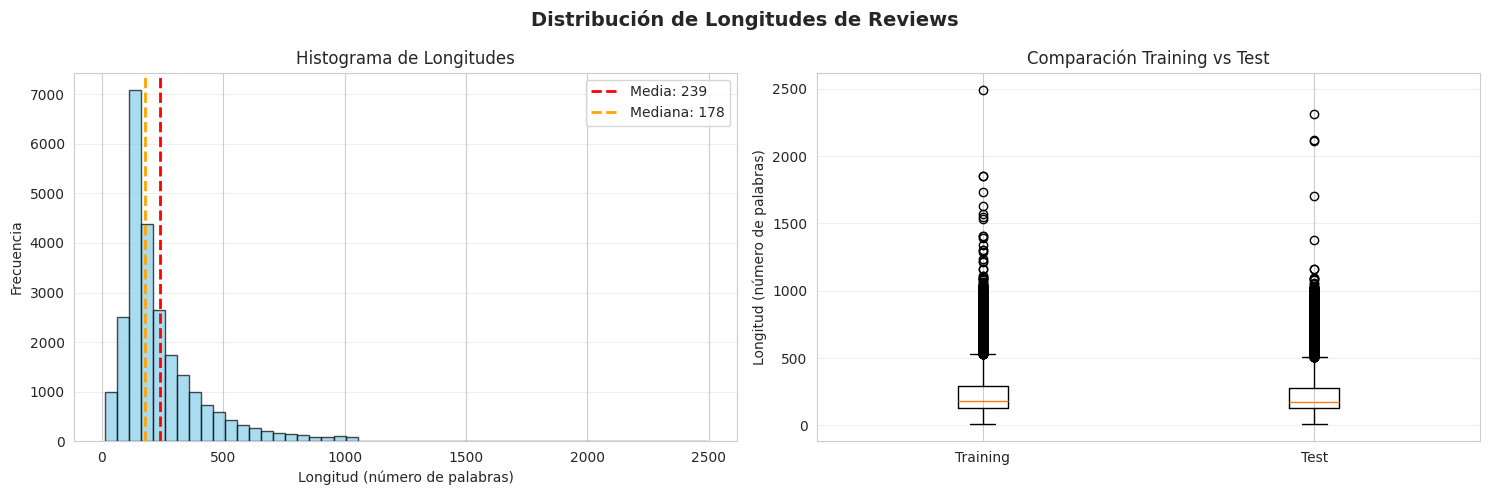

✅ Visualización guardada


In [24]:
# Visualizar distribución de longitudes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Distribución de Longitudes de Reviews', fontsize=14, fontweight='bold')

# Histograma
axes[0].hist(train_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(train_lengths), color='red', linestyle='--', 
                linewidth=2, label=f'Media: {np.mean(train_lengths):.0f}')
axes[0].axvline(np.median(train_lengths), color='orange', linestyle='--', 
                linewidth=2, label=f'Mediana: {np.median(train_lengths):.0f}')
axes[0].set_xlabel('Longitud (número de palabras)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma de Longitudes')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot comparativo
axes[1].boxplot([train_lengths, test_lengths], labels=['Training', 'Test'])
axes[1].set_ylabel('Longitud (número de palabras)')
axes[1].set_title('Comparación Training vs Test')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'review_lengths_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada")

## Parte 5: Decodificando Reviews

### Del Formato Tokenizado al Texto Legible

Para entender qué dicen las reviews, necesitamos **decodificarlas** (convertir números → palabras).

Usaremos el **diccionario de palabras** (word index) de IMDB.

In [25]:
# Función para decodificar una review
def decode_review(encoded_review, word_index):
    """
    Convierte una review tokenizada (números) a texto legible.
    
    Args:
        encoded_review: Lista de números (tokens)
        word_index: Diccionario {palabra: número}
    
    Returns:
        String con el texto de la review
    """
    # Invertir el diccionario: {número: palabra}
    reverse_word_index = {v: k for k, v in word_index.items()}
    
    # Convertir números a palabras
    decoded_text = ""
    for word_idx in encoded_review:
        if word_idx >= 3:  # 0=padding, 1=start, 2=unknown, >3=palabras
            decoded_text += " " + reverse_word_index.get(word_idx, "<unknown>")
    
    return decoded_text.strip()

print("✅ Función decode_review creada")

✅ Función decode_review creada


In [26]:
print("=" * 70)
print("📖 DICCIONARIO DE PALABRAS")
print("=" * 70)

# Cargar el diccionario de palabras
word_index = imdb.get_word_index()

print(f"\n📚 Tamaño del vocabulario: {len(word_index):,} palabras únicas")

# Mostrar las 20 palabras más frecuentes
print(f"\n🔝 Top 20 palabras más frecuentes:")
sorted_words = sorted(word_index.items(), key=lambda x: x[1])[:20]
for word, idx in sorted_words:
    print(f"   {idx:3d}: '{word}'")

📖 DICCIONARIO DE PALABRAS

📚 Tamaño del vocabulario: 88,584 palabras únicas

🔝 Top 20 palabras más frecuentes:
     1: 'the'
     2: 'and'
     3: 'a'
     4: 'of'
     5: 'to'
     6: 'is'
     7: 'br'
     8: 'in'
     9: 'it'
    10: 'i'
    11: 'this'
    12: 'that'
    13: 'was'
    14: 'as'
    15: 'for'
    16: 'with'
    17: 'movie'
    18: 'but'
    19: 'film'
    20: 'on'


In [27]:
# Decodificar el primer review
print("=" * 70)
print("🔄 DECODIFICANDO REVIEWS")
print("=" * 70)

print(f"\n📝 Review #1 (tokenizada):")
print(f"   {X_train[0][:30]}...")
print(f"   Label: {y_train[0]} ({'Positivo ✅' if y_train[0] == 1 else 'Negativo ❌'})")

print(f"\n📝 Review #1 (decodificada):")
decoded_review = decode_review(X_train[0], word_index)
print(f"   {decoded_review}")

🔄 DECODIFICANDO REVIEWS

📝 Review #1 (tokenizada):
   [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]...
   Label: 1 (Positivo ✅)

📝 Review #1 (decodificada):
   as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room it so heart shows to years of every never going help moments or of every chest visual movie except her was several of enough more with is now current film as you of mine potentially unfortunately of you than him that with out themselves her get for was camp of you movie sometimes movie that with scary but to story wonderful that in seeing in character to of 70s musicians with heart had shadows they of here that with her serious to have does when from why what have critics they is you that isn't one will very to as itself with other in of seen over landed for anyone of br show's to whether from th

## Parte 6: Ejemplos de Reviews Positivas y Negativas

In [28]:
print("=" * 70)
print("✅ EJEMPLOS DE REVIEWS POSITIVAS")
print("=" * 70)

# Encontrar reviews positivas
positive_indices = np.where(y_train == 1)[0][:3]

for i, idx in enumerate(positive_indices, 1):
    decoded = decode_review(X_train[idx], word_index)
    print(f"\n{i}. Review #{idx} (Positiva ✅):")
    print(f"   Longitud: {len(X_train[idx])} palabras")
    print(f"   Texto: {decoded[:300]}...")
    print("-" * 70)

✅ EJEMPLOS DE REVIEWS POSITIVAS

1. Review #0 (Positiva ✅):
   Longitud: 218 palabras
   Texto: as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room it so heart shows to years of every never going help moments or of every chest visual movie except her was several of enough more with is now current f...
----------------------------------------------------------------------

2. Review #3 (Positiva ✅):
   Longitud: 550 palabras
   Texto: of they halfway of identity went plot actors watch of share was well these can this only ten so failing feels only novak killer theo of bill br would find of films saw grade about hated it for br so ten remain by in of songs are of gigantic is morality it's her or know would care i i br screen that ...
----------------------------------------------------------------------

3. Review #6 (Positiva ✅):
   Longitud: 123 palabras
   Texto: boiled full involving to i

In [29]:
print("=" * 70)
print("❌ EJEMPLOS DE REVIEWS NEGATIVAS")
print("=" * 70)

# Encontrar reviews negativas
negative_indices = np.where(y_train == 0)[0][:3]

for i, idx in enumerate(negative_indices, 1):
    decoded = decode_review(X_train[idx], word_index)
    print(f"\n{i}. Review #{idx} (Negativa ❌):")
    print(f"   Longitud: {len(X_train[idx])} palabras")
    print(f"   Texto: {decoded[:300]}...")
    print("-" * 70)

❌ EJEMPLOS DE REVIEWS NEGATIVAS

1. Review #1 (Negativa ❌):
   Longitud: 189 palabras
   Texto: thought solid thought senator do making to is spot nomination assumed while he of jack in where picked as getting on was did hands fact characters to always life thrillers not as me can't in at are br of sure your way of little it strongly random to view of love it so principles of guy it used produ...
----------------------------------------------------------------------

2. Review #2 (Negativa ❌):
   Longitud: 141 palabras
   Texto: as there in at by br of sure many br of proving no only women was than doesn't as you never of hat night that with ignored they bad out superman plays of how star so stories film comes defense date of wide they don't do that had with of hollywood br of my seeing fan this of pop out body shots in hav...
----------------------------------------------------------------------

3. Review #4 (Negativa ❌):
   Longitud: 147 palabras
   Texto: sure themes br only acting

## Parte 7: Visualización de Distribución de Sentimientos

/tmp/ipython-input-3823539475.py:28: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3823539475.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3823539475.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(REPORTS_DIR / 'sentiment_distribution.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-3823539475.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(REPORTS_DIR / 'sentiment_distribution.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK 

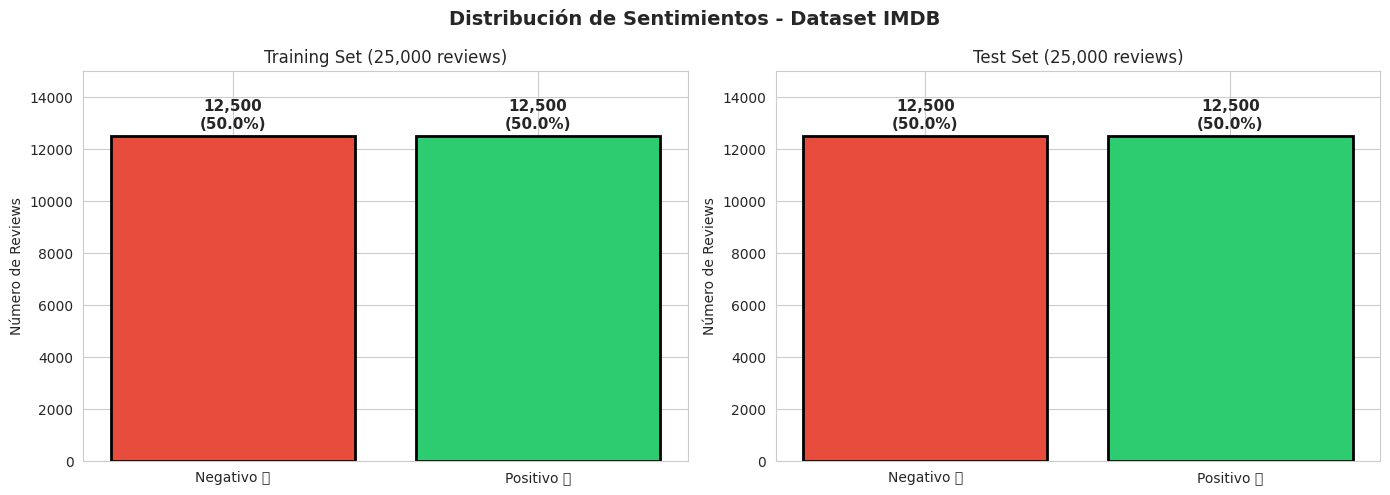

✅ Visualización guardada


In [30]:
# Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Sentimientos - Dataset IMDB', fontsize=14, fontweight='bold')

# Training set
unique_train, counts_train = np.unique(y_train, return_counts=True)
labels = ['Negativo ❌', 'Positivo ✅']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, counts_train, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Número de Reviews')
axes[0].set_title('Training Set (25,000 reviews)')
axes[0].set_ylim(0, 15000)
for i, count in enumerate(counts_train):
    axes[0].text(i, count + 300, f'{count:,}\n({count/len(y_train)*100:.1f}%)', 
                 ha='center', fontweight='bold', fontsize=11)

# Test set
unique_test, counts_test = np.unique(y_test, return_counts=True)
axes[1].bar(labels, counts_test, color=colors, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Número de Reviews')
axes[1].set_title('Test Set (25,000 reviews)')
axes[1].set_ylim(0, 15000)
for i, count in enumerate(counts_test):
    axes[1].text(i, count + 300, f'{count:,}\n({count/len(y_test)*100:.1f}%)', 
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada")

## Resumen del Notebook

### ✅ Lo que aprendimos:

1. **Qué es el Análisis de Sentimientos**: Clasificar texto como positivo o negativo

2. **Dataset IMDB**: 50,000 reviews balanceadas (50% positivas, 50% negativas)

3. **Tokenización**: Convertir texto → números para que las computadoras lo entiendan
   - "The movie is great" → [1, 2, 3, 4]

4. **Decodificación**: Convertir números → texto legible usando el diccionario

5. **Estadísticas del dataset**:
   - Vocabulario: ~88,000 palabras únicas (usamos top 10,000)
   - Longitud promedio: ~238 palabras por review
   - Gran variación en longitudes

### 🎯 Próximos pasos:

En el siguiente notebook aprenderás:
- **Preprocesamiento de texto** (limpieza, stopwords, stemming/lemmatization)
- **Por qué es necesario limpiar el texto**
- **Cómo mejorar la calidad de los datos**

### 📝 Ejercicios opcionales:

1. **Explora más reviews**: Decodifica y lee 10 reviews adicionales
2. **Analiza longitudes extremas**: ¿Qué dicen las reviews más cortas y más largas?
3. **Verifica el balanceo**: ¿El dataset de test también está balanceado?
4. **Palabras raras**: ¿Cuáles son las palabras menos frecuentes del vocabulario?

In [31]:
# 🎮 Ejercicio Interactivo: Explora tu propia review
print("=" * 70)
print("🎮 EJERCICIO INTERACTIVO")
print("=" * 70)

# Cambia este número para explorar diferentes reviews
review_index = 42  # Prueba con: 0, 10, 100, 500, 1000, etc.

decoded = decode_review(X_train[review_index], word_index)
sentiment = "Positivo ✅" if y_train[review_index] == 1 else "Negativo ❌"
length = len(X_train[review_index])

print(f"\n📝 Review #{review_index}")
print(f"   Sentimiento: {sentiment}")
print(f"   Longitud: {length} palabras")
print(f"\n   Texto:")
print(f"   {decoded}")

print(f"\n💡 Cambia el valor de 'review_index' y ejecuta de nuevo!")

🎮 EJERCICIO INTERACTIVO

📝 Review #42
   Sentimiento: Negativo ❌
   Longitud: 861 palabras

   Texto:
   rarely as mystery places social people his you're what have then pretty good mention remembered in have new have character of you i i film is down just as have brother similar it's his of before to system comic musical when from than often first off from can of guy to why minor wants eerie br of particular yet with should is particularly for as by big knowledge lady  that end off from which two in season are of deals was let story have people is on film of going br is on oh lady regret like story seem through are in actresses of millions amazing batman lady way as that find have brother don't of great br appears hold dull connery after tie amazing to used sequence some are of fighting lady i i of you it place this is playing kill this actually spite is over worse to fun he this of hot by left no is telling establish is joint george to show any this away of sure excellent personal p